# Traffic Demand Prediction - Train EDA

This notebook profiles `train.csv`, checks data quality, studies demand behavior, and identifies modeling signals.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dataset').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'dataset'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_PATH = DATA_DIR / 'sample_submission.csv'

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/underxcore/Desktop/Flipkart_GridLock


In [2]:
train = pd.read_csv(TRAIN_PATH)
train.shape

(77299, 11)

In [3]:
display(train.head())
display(train.info())

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.0488,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.1185,Residential,3,Allowed,Yes,31.1046,Sunny
2,2,qp08bj,48,0:0,0.0271,Residential,1,Not Allowed,No,25.9193,Sunny
3,3,qp08gt,48,0:0,0.0033,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.0108,Residential,1,Not Allowed,No,10.8037,Rainy


<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 6.5 MB


None

## Data Quality

In [4]:
missing = train.isna().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(train) * 100).round(2)
missing

,missing_count,missing_pct
Index,0,0.0000
geohash,0,0.0000
day,0,0.0000
timestamp,0,0.0000
demand,0,0.0000
RoadType,600,0.7800
NumberofLanes,0,0.0000
LargeVehicles,0,0.0000
Landmarks,0,0.0000
Temperature,2495,3.2300


In [5]:
duplicates = train.duplicated(subset=['Index']).sum()
print(f'Duplicate Index values: {duplicates}')
print(f'Index monotonic increasing: {train.Index.is_monotonic_increasing}')

Duplicate Index values: 0
Index monotonic increasing: True


## Target Distribution

count   77,299.0000
mean         0.0939
std          0.1422
min          0.0000
1%           0.0006
5%           0.0032
25%          0.0182
50%          0.0478
75%          0.1086
95%          0.3359
99%          0.8623
max          1.0000
Name: demand, dtype: float64

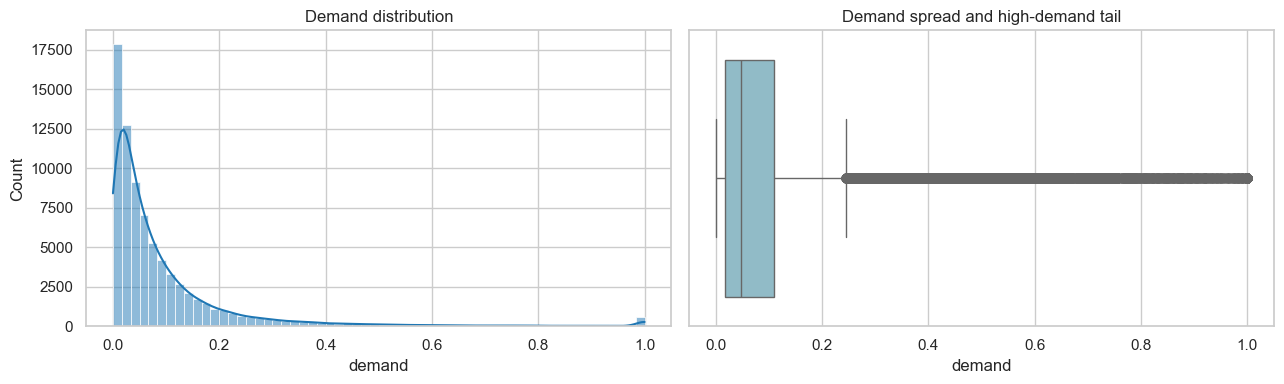

In [6]:
display(train['demand'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train['demand'], bins=60, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Demand distribution')
sns.boxplot(x=train['demand'], ax=axes[1], color='#88c0d0')
axes[1].set_title('Demand spread and high-demand tail')
plt.tight_layout()

## Temporal Patterns

In [7]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    hm = out['timestamp'].astype(str).str.split(':', expand=True).astype(int)
    out['hour'] = hm[0]
    out['minute'] = hm[1]
    out['minute_of_day'] = out['hour'] * 60 + out['minute']
    out['global_minute'] = out['day'] * 24 * 60 + out['minute_of_day']
    out['time_sin'] = np.sin(2 * np.pi * out['minute_of_day'] / (24 * 60))
    out['time_cos'] = np.cos(2 * np.pi * out['minute_of_day'] / (24 * 60))
    out['is_morning_peak'] = out['hour'].between(7, 10).astype(int)
    out['is_evening_peak'] = out['hour'].between(16, 20).astype(int)
    out['is_night'] = ((out['hour'] <= 5) | (out['hour'] >= 22)).astype(int)
    return out

train_time = add_time_features(train)
train_time[['day', 'timestamp', 'hour', 'minute', 'minute_of_day', 'global_minute']].head()

,day,timestamp,hour,minute,minute_of_day,global_minute
0,48,0:0,0,0,0,69120
1,48,0:0,0,0,0,69120
2,48,0:0,0,0,0,69120
3,48,0:0,0,0,0,69120
4,48,0:0,0,0,0,69120


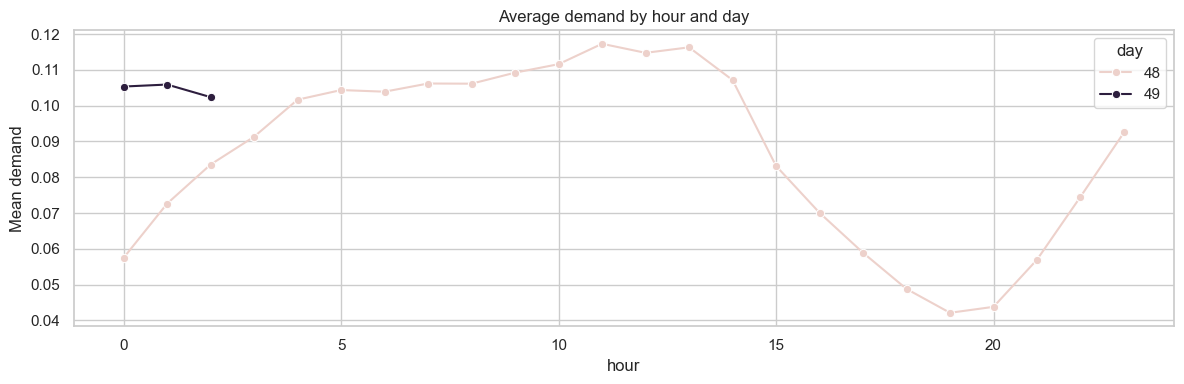

In [8]:
temporal = train_time.groupby(['day', 'hour'], as_index=False)['demand'].agg(['mean', 'median', 'count']).reset_index()
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=temporal, x='hour', y='mean', hue='day', marker='o', ax=ax)
ax.set_title('Average demand by hour and day')
ax.set_ylabel('Mean demand')
plt.tight_layout()

## Categorical Signals

In [9]:
cat_cols = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'NumberofLanes']
for col in cat_cols:
    summary = train.groupby(col, dropna=False)['demand'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
    print(f'\n{col}')
    display(summary)


RoadType


,count,mean,median
RoadType,,,
Highway,3560,0.6108,0.5264
Street,3909,0.2732,0.2681
NaN,600,0.0983,0.0481
Residential,69230,0.0572,0.0405



LargeVehicles


,count,mean,median
LargeVehicles,,,
Allowed,26626,0.1319,0.0512
Not Allowed,50673,0.0740,0.0460



Landmarks


,count,mean,median
Landmarks,,,
No,25257,0.0963,0.0456
Yes,52042,0.0928,0.0490



Weather


,count,mean,median
Weather,,,
NaN,797,0.0972,0.0501
Rainy,20824,0.0945,0.0485
Sunny,27717,0.0942,0.0472
Foggy,20243,0.0934,0.0476
Snowy,7718,0.0926,0.0478



NumberofLanes


,count,mean,median
NumberofLanes,,,
5,916,0.6076,0.5217
4,926,0.6029,0.5131
1,27411,0.0881,0.0522
3,23919,0.0779,0.0428
2,24127,0.0775,0.0430


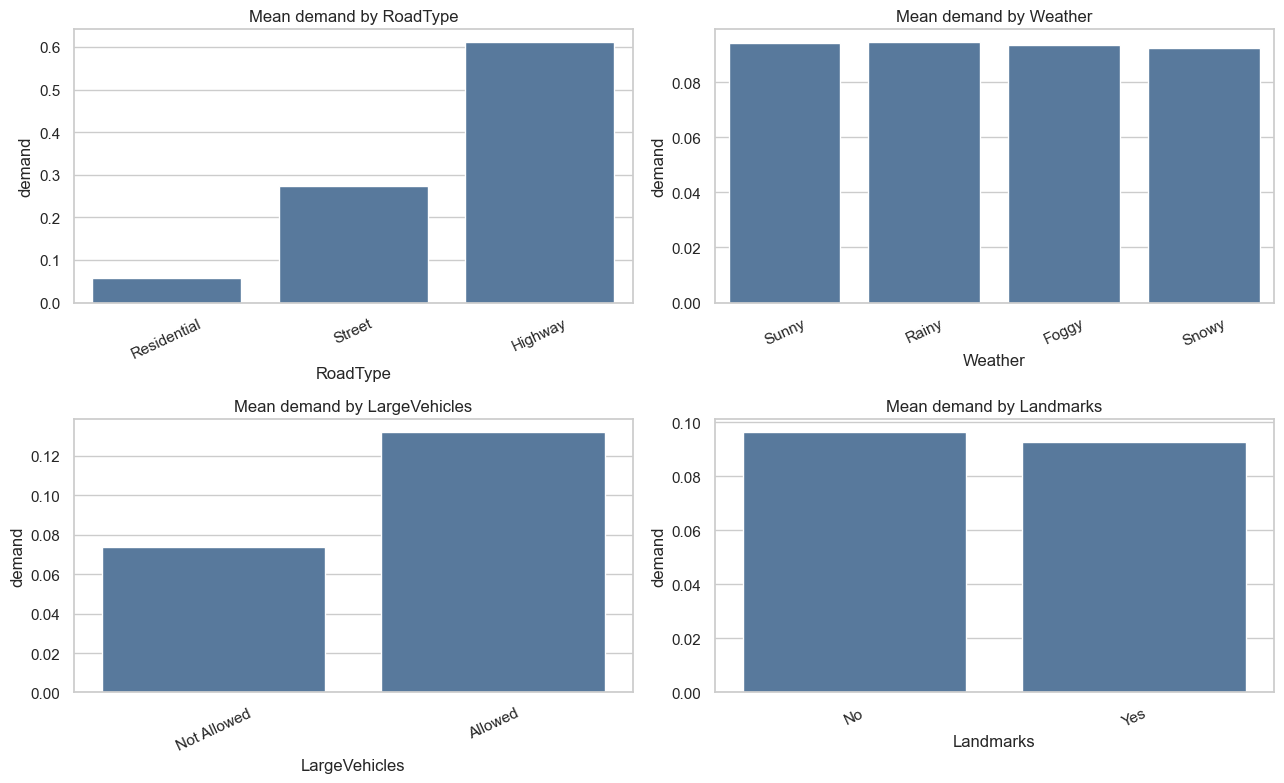

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']):
    sns.barplot(data=train, x=col, y='demand', estimator='mean', errorbar=None, ax=ax, color='#4c78a8')
    ax.set_title(f'Mean demand by {col}')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()

## Geohash Demand Hotspots

In [11]:
geo_summary = train.groupby('geohash')['demand'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False)
display(geo_summary.head(15))
display(geo_summary.sort_values('count', ascending=False).head(15))

,count,mean,median
geohash,,,
qp09d9,105,0.9607,1.0000
qp09ft,105,0.8689,1.0000
qp09e5,105,0.8650,1.0000
qp09d8,105,0.6693,0.7339
qp096x,105,0.6656,0.7715
qp09d2,105,0.6647,0.6968
qp09dc,105,0.6615,0.8215
qp096r,105,0.6505,0.6594
qp09d3,105,0.6435,0.6850


,count,mean,median
geohash,,,
qp09d9,105,0.9607,1.0000
qp03z8,105,0.1316,0.1286
qp03xv,105,0.1741,0.1571
qp092n,105,0.1715,0.1770
qp092j,105,0.1646,0.1674
qp09t0,105,0.1645,0.1654
qp092k,105,0.1613,0.1610
qp03zf,105,0.1516,0.1571
qp09fq,105,0.1497,0.1252


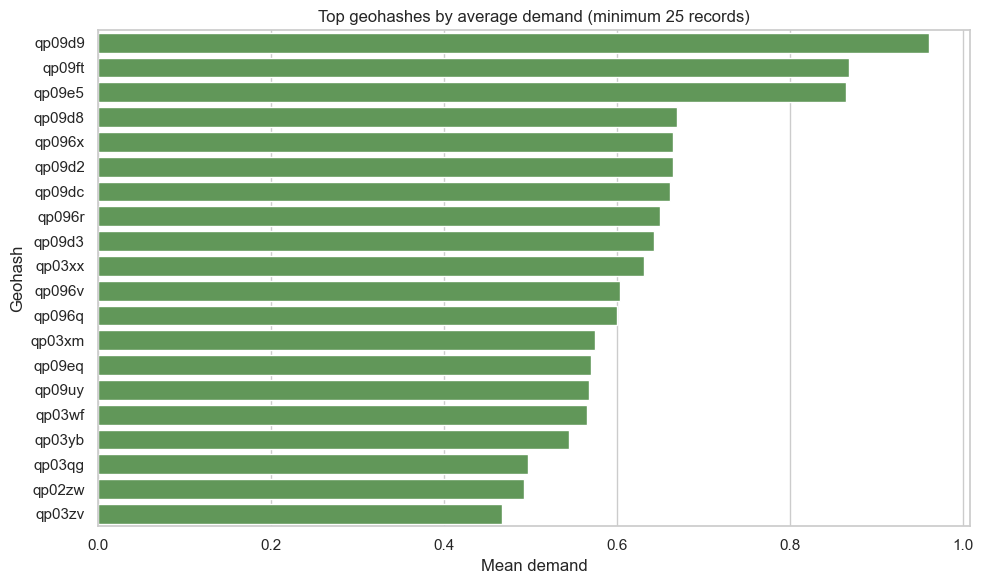

In [12]:
top_geo = geo_summary.query('count >= 25').head(20).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_geo, y='geohash', x='mean', color='#59a14f')
plt.title('Top geohashes by average demand (minimum 25 records)')
plt.xlabel('Mean demand')
plt.ylabel('Geohash')
plt.tight_layout()

## EDA Notes

- Missing values are low and should be imputed in the modeling pipeline.
- Demand is right-skewed and bounded, so predictions should be clipped to `[0, 1]`.
- Time of day, geohash, weather, road type, and vehicle/landmark indicators are natural modeling signals.